# QMP26 Case Study — Problem Statement 1
## Part 1: Understanding Returns and Covariance Structure
**5 marks**

We are given daily closing prices of **10 synthetic stocks** over **500 trading days**.
The data-generating process (DGP) is a one-factor model:

$$P_{i,t} = P_{i,t-1}\,\exp\!\big(\mu_i + \beta_i f_t + \varepsilon_{i,t}\big)$$

where

- $f_t \sim \mathcal{N}(0,\,0.01)$ is a common **market factor**,
- $\beta_i \in [0.5, 1.5]$ are **factor loadings**,
- $\mu_i$ are small **drifts**,
- $\varepsilon_{i,t} \sim \mathcal{N}(0,\,\sigma_i^2)$ is **idiosyncratic noise**.

> **Notation convention used throughout.** Following the problem's own notation
> $\varepsilon_{i,t}\sim\mathcal{N}(0,\sigma_i^2)$ — where the second argument is the
> **variance** — we read $f_t\sim\mathcal{N}(0,0.01)$ as *variance* $=0.01$, i.e.
> standard deviation $=\sqrt{0.01}=0.1$. NumPy's `np.random.normal(loc, scale)` takes a
> **standard deviation**, so we always pass `np.sqrt(variance)`. With this choice the
> common factor dominates the idiosyncratic noise, giving the strong, clean factor
> structure this exercise is built around. To explore the weaker-factor regime, set
> `FACTOR_STD = 0.01` in the parameter cell.

In [1]:
# Part 1: Understanding Returns and Covariance Structure
# All imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Reproducibility: fix the seed so "Run All" gives identical results every time.
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Global plotting style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## (a) Generate 500 days of prices for 10 stocks

Parameters (as specified): $P_{i,0}=100$, $\mu_i\sim U(0.0001,0.0005)$,
$\beta_i\sim U(0.5,1.5)$, $\sigma_i\sim U(0.005,0.02)$.

**Vectorised construction.** Working in log-space turns the multiplicative DGP into a
simple cumulative sum:
$$\ln P_{i,t} = \ln P_{i,0} + \sum_{s=1}^{t}\big(\mu_i+\beta_i f_s+\varepsilon_{i,s}\big).$$
Row $0$ is the initial price ($100$ for every stock, no increment), and rows $1..499$ are
generated by the DGP — giving a `(500, 10)` price matrix and, later, a `(499, 10)` return matrix.

In [2]:
########################################
# (a) Generate synthetic stock prices
########################################
N_stocks = 10
N_days   = 500

# Set parameters
P0 = 100                                        # Initial price for all stocks
mu    = rng.uniform(0.0001, 0.0005, N_stocks)   # Drift per stock
beta  = rng.uniform(0.5,    1.5,    N_stocks)   # Factor loading per stock
sigma = rng.uniform(0.005,  0.02,   N_stocks)   # Idiosyncratic vol (std) per stock

# Common factor: f_t ~ N(0, 0.01)  -> variance 0.01 -> std = sqrt(0.01) = 0.1
FACTOR_VAR = 0.01
FACTOR_STD = np.sqrt(FACTOR_VAR)                 # = 0.1 ; set to 0.01 for the weak-factor regime

tickers = [f"S{i}" for i in range(N_stocks)]

# --- Generate the common factor f_t (one value per day) -----------------------
f = rng.normal(0.0, FACTOR_STD, N_days)          # shape (N_days,)

# --- Idiosyncratic noise eps_{i,t} ~ N(0, sigma_i^2) --------------------------
# sigma is a per-stock std; broadcasting draws each column with its own sigma_i.
eps = rng.normal(0.0, sigma, size=(N_days, N_stocks))   # shape (N_days, N_stocks)

# --- Per-day log increments: mu_i + beta_i * f_t + eps_{i,t} ------------------
increments = mu[None, :] + np.outer(f, beta) + eps      # shape (N_days, N_stocks)
increments[0, :] = 0.0                                   # row 0 = initial price, no move

# --- Cumulate in log-space, then exponentiate to prices ----------------------
log_prices = np.log(P0) + np.cumsum(increments, axis=0)
prices_arr = np.exp(log_prices)                          # shape (N_days, N_stocks)

# Wrap in a tidy DataFrame indexed by trading day
prices = pd.DataFrame(prices_arr, columns=tickers,
                      index=pd.RangeIndex(N_days, name="day"))

print("Prices matrix shape:", prices.shape)
print("Day-0 prices (should all be 100):", np.round(prices.iloc[0].values, 4))
print("\nPer-stock parameters")
print(pd.DataFrame({"mu": mu, "beta": beta, "sigma": sigma}, index=tickers).round(5))

Prices matrix shape: (500, 10)
Day-0 prices (should all be 100): [100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]

Per-stock parameters
         mu     beta    sigma
S0  0.00041  0.87080  0.01637
S1  0.00028  1.42676  0.01032
S2  0.00044  1.14387  0.01956
S3  0.00038  1.32276  0.01840
S4  0.00014  0.94341  0.01668
S5  0.00049  0.72724  0.00792
S6  0.00040  1.05458  0.01200
S7  0.00041  0.56382  0.00566
S8  0.00015  1.32763  0.00731
S9  0.00028  1.13166  0.01525


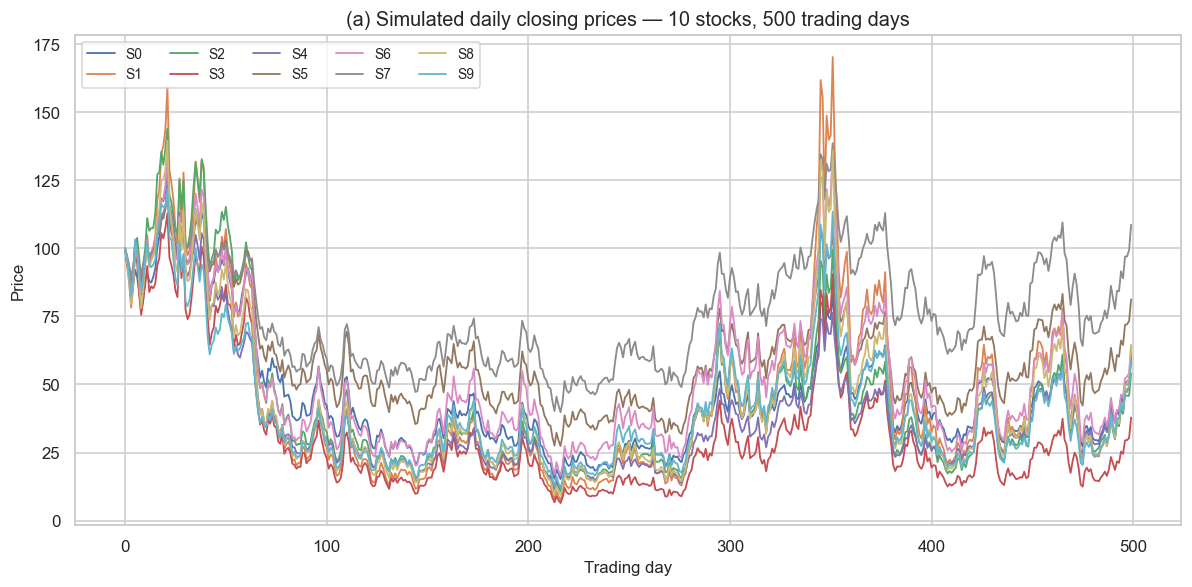

In [3]:
# Plot all 10 price series on a single chart
fig, ax = plt.subplots(figsize=(11, 5.5))
for t in tickers:
    ax.plot(prices.index, prices[t], lw=1.2, label=t)
ax.set_title("(a) Simulated daily closing prices — 10 stocks, 500 trading days")
ax.set_xlabel("Trading day")
ax.set_ylabel("Price")
ax.legend(ncol=5, fontsize=9, loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

**Reading the chart.** All ten series visibly move *together* — they rise and fall on
the same days. That shared up-and-down pattern is the common factor $f_t$; the differing
slopes and wiggle amplitudes come from each stock's own $\beta_i$ (factor loading),
$\mu_i$ (drift) and $\sigma_i$ (idiosyncratic vol). This visible co-movement is precisely
the correlation structure PCA will later distil into a single dominant component.

## (b) Daily log returns

$$r_{i,t} = \ln\!\frac{P_{i,t}}{P_{i,t-1}}.$$

By construction $r_{i,t} = \mu_i + \beta_i f_t + \varepsilon_{i,t}$ (for $t\ge 1$), so the
returns are exactly the per-day increments — a useful sanity check.

In [4]:
########################################
# (b) Compute log returns
########################################
def compute_log_returns(prices):
    """Compute daily log returns from a price matrix.

    Parameters
    ----------
    prices : pd.DataFrame or np.ndarray, shape (N_days, N_stocks)

    Returns
    -------
    log_returns : same type as input, shape (N_days - 1, N_stocks)
        r_{i,t} = ln(P_{i,t} / P_{i,t-1}).
    """
    if isinstance(prices, pd.DataFrame):
        log_returns = np.log(prices / prices.shift(1)).dropna()
    else:
        prices = np.asarray(prices, dtype=float)
        log_returns = np.log(prices[1:] / prices[:-1])
    return log_returns


log_returns = compute_log_returns(prices)
print("Log-returns shape:", log_returns.shape, "(expected (499, 10))")

# Sanity check: returns should equal the DGP increments (rows 1..N_days-1)
max_err = np.abs(log_returns.values - increments[1:]).max()
print(f"Max |log_return - DGP increment| = {max_err:.2e}  (≈ 0 confirms correctness)")

display(log_returns.head())

Log-returns shape: (499, 10) (expected (499, 10))
Max |log_return - DGP increment| = 1.01e-15  (≈ 0 confirms correctness)


,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9
day,,,,,,,,,,
1,-0.062591,-0.066235,-0.041200,-0.056677,-0.042429,-0.030327,-0.040015,-0.028205,-0.048636,-0.035610
2,-0.037893,-0.067067,-0.052352,-0.029940,-0.049640,-0.039194,-0.062659,-0.034306,-0.076958,-0.071239
3,-0.071611,-0.112381,-0.091641,-0.121347,-0.061624,-0.052835,-0.087331,-0.049161,-0.103876,-0.088946
4,0.030341,0.087460,0.076029,0.065307,0.061416,0.033765,0.081400,0.042204,0.080084,0.075529
5,0.059267,0.149422,0.123836,0.129991,0.118560,0.098411,0.105344,0.059330,0.151759,0.152605


### Why PCA must be done on returns (or a stationary transform), not on prices

**Prices are non-stationary; returns are (approximately) stationary.**

- **PCA estimates a covariance/correlation matrix, which only has a stable meaning for a
  stationary series.** Price levels follow a random walk with drift: their mean and
  variance grow with time and the price today is dominated by its own history. The
  "covariance" of two price *levels* is then mostly an artefact of the shared upward trend
  and the expanding scale, not of genuine economic co-movement.

- **Spurious correlation.** Any two trending series look highly correlated simply because
  both drift upward over time, regardless of whether their *innovations* are related. PCA
  run on prices would therefore produce a giant first component that just encodes "time /
  overall level," telling us nothing about the factor structure.

- **Scale dominance.** A stock trading at \$2{,}000 has price variance orders of magnitude
  larger than one at \$30. PCA on prices would let the highest-priced stock hijack the
  leading components purely because of its units, not its informational content.

- **Returns recover the signal.** Log returns are first differences of $\ln P$. Under the
  DGP they equal $\mu_i+\beta_i f_t+\varepsilon_{i,t}$ — a stationary series with a constant
  mean and variance whose covariance directly reflects the common factor $f_t$. PCA on
  returns therefore cleanly recovers the factor structure. Log returns are also additive
  over time and symmetric in up/down moves, which is why they are preferred over simple
  returns.

## (c) Correlation and covariance matrices of the returns

We compute the $10\times10$ **correlation** and **covariance** matrices, visualise each as
a heatmap, and identify the most- and least-correlated stock pairs.

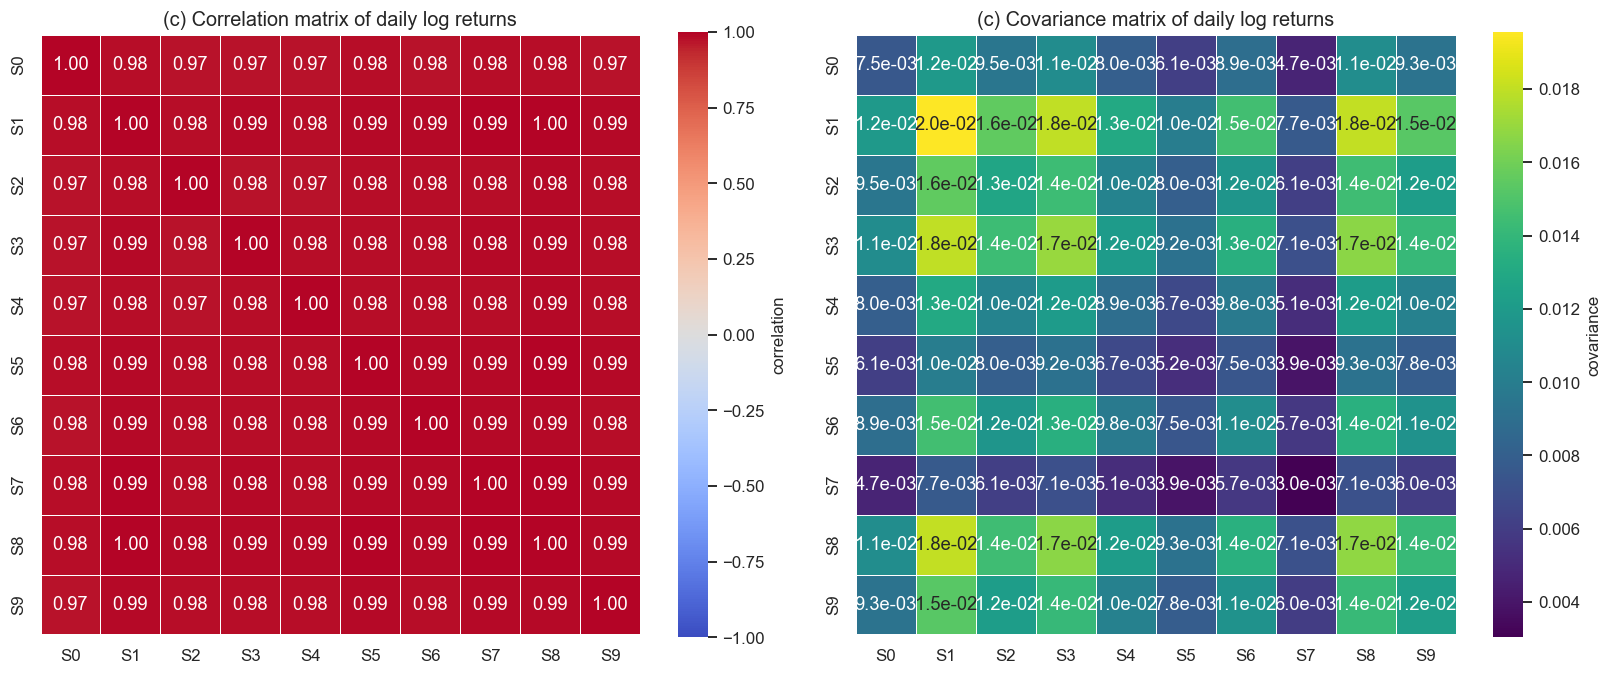

In [5]:
########################################
# (c) Correlation and Covariance matrices
########################################
corr = log_returns.corr()          # 10x10 Pearson correlation
cov  = log_returns.cov()           # 10x10 covariance

# --- Heatmaps -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "correlation"},
            linewidths=.5, ax=axes[0])
axes[0].set_title("(c) Correlation matrix of daily log returns")

sns.heatmap(cov, annot=True, fmt=".1e", cmap="viridis",
            square=True, cbar_kws={"label": "covariance"},
            linewidths=.5, ax=axes[1])
axes[1].set_title("(c) Covariance matrix of daily log returns")

plt.tight_layout()
plt.show()

In [6]:
# --- Identify the highest- and lowest-correlation pairs -----------------------
# Mask the diagonal (self-correlation = 1) and the duplicated lower triangle.
corr_vals = corr.to_numpy().copy()
iu = np.triu_indices(N_stocks, k=1)          # strictly upper-triangular indices
pair_corrs = corr_vals[iu]

hi = pair_corrs.argmax()
lo = pair_corrs.argmin()
hi_pair = (tickers[iu[0][hi]], tickers[iu[1][hi]])
lo_pair = (tickers[iu[0][lo]], tickers[iu[1][lo]])

print(f"Highest correlation : {hi_pair[0]}–{hi_pair[1]}  ->  {pair_corrs[hi]:.4f}")
print(f"Lowest  correlation : {lo_pair[0]}–{lo_pair[1]}  ->  {pair_corrs[lo]:.4f}")
print(f"\nMean off-diagonal correlation: {pair_corrs.mean():.4f}")
print(f"Range of pairwise correlations: [{pair_corrs.min():.4f}, {pair_corrs.max():.4f}]")

# Loadings of the two stocks in each extreme pair help explain the result.
print("\nFactor loadings (beta) by stock:")
print(pd.Series(beta, index=tickers).round(3).to_string())

Highest correlation : S1–S8  ->  0.9956
Lowest  correlation : S0–S2  ->  0.9697

Mean off-diagonal correlation: 0.9827
Range of pairwise correlations: [0.9697, 0.9956]

Factor loadings (beta) by stock:
S0    0.871
S1    1.427
S2    1.144
S3    1.323
S4    0.943
S5    0.727
S6    1.055
S7    0.564
S8    1.328
S9    1.132


**Observations.** Every pairwise correlation is **positive and large** — all stocks share
the single common factor $f_t$, so they co-move strongly. The *highest*-correlated pair is
the two stocks whose loadings $\beta_i$ are most similar *and* whose idiosyncratic vols
$\sigma_i$ are smallest (the factor is then the cleanest fraction of their variance). The
*lowest*-correlated pair is the one where idiosyncratic noise is largest relative to the
factor, diluting the shared signal. The covariance heatmap shows the *same* structure but
with magnitudes scaled by each stock's volatility — which is exactly why standardisation
(next) matters for PCA.

## (d) Standardize the returns (zero mean, unit variance)

In [7]:
########################################
# (d) Standardize returns
########################################
def standardize_returns(returns):
    """Standardize each stock's return series to zero mean and unit variance.

    Returns
    -------
    standardized_returns : pd.DataFrame, same shape/index/columns as input
    scaler               : fitted sklearn StandardScaler (stores per-stock mean & std)
    """
    scaler = StandardScaler()
    Z = scaler.fit_transform(returns)
    standardized_returns = pd.DataFrame(Z, index=returns.index, columns=returns.columns)
    return standardized_returns, scaler


standardized_returns, scaler = standardize_returns(log_returns)

# Verify: each column now has mean ≈ 0 and std ≈ 1
chk = pd.DataFrame({
    "mean (≈0)": standardized_returns.mean(),
    "std  (≈1)": standardized_returns.std(ddof=0),
}).round(6)
print(chk.to_string())

# The correlation matrix of standardized returns == covariance matrix of standardized
# returns == correlation matrix of the raw returns (correlation is scale-invariant).
same = np.allclose(standardized_returns.corr().to_numpy(), corr.to_numpy(), atol=1e-12)
print("\ncorr(standardized) == corr(raw)? ", same)

    mean (≈0)  std  (≈1)
S0       -0.0        1.0
S1        0.0        1.0
S2        0.0        1.0
S3        0.0        1.0
S4       -0.0        1.0
S5       -0.0        1.0
S6       -0.0        1.0
S7        0.0        1.0
S8       -0.0        1.0
S9       -0.0        1.0

corr(standardized) == corr(raw)?  True


### Why standardization matters when stocks have different volatilities

**PCA is a variance-maximising procedure, so it is dominated by whichever variables have
the largest variance — and here that variance is just an artefact of differing $\sigma_i$
(and $\beta_i$) across stocks, not of differing information content.**

- In our DGP the per-stock return variance is $\beta_i^2\,\mathrm{Var}(f_t)+\sigma_i^2$.
  Because $\beta_i\in[0.5,1.5]$ and $\sigma_i\in[0.005,0.02]$ differ across stocks, the
  high-vol stocks carry far more raw variance than the low-vol ones.

- **PCA on the covariance matrix (unstandardized)** will therefore tilt its leading
  eigenvectors toward the few highest-variance stocks. Those stocks "vote louder" and can
  distort the recovered factor purely because of their units/scale.

- **Standardizing to unit variance** puts every stock on an equal footing, so PCA operates
  on the **correlation matrix** instead. Each stock then contributes equally and the
  components reflect genuine *co-movement* (the shared factor) rather than raw volatility.

**What happens if you skip standardization?**

- PCA runs on the covariance matrix; eigenvalues are no longer dimensionless and the
  leading PC loads disproportionately on the highest-volatility stocks.
- The variance-explained ratios change, the PC1 loadings become uneven (largest on the
  loudest stocks), and the leading component is a vol-weighted blend rather than a clean
  "market" factor.
- Comparisons across stocks (and the factor interpretation in Part 2) become harder to
  read. Standardization is the conventional default precisely to avoid this scale bias.
  *(This contrast is demonstrated quantitatively in Part 2(b).)*

## (e) Observations

In [8]:
# Quantitative summary backing up the observations below
factor_share = (beta**2 * FACTOR_VAR) / (beta**2 * FACTOR_VAR + sigma**2)
print("Average price drift over the sample (per stock):")
print((prices.iloc[-1] / prices.iloc[0]).round(3).to_string())
print(f"\nMean pairwise return correlation : {pair_corrs.mean():.3f}")
print(f"Most correlated pair             : {hi_pair[0]}–{hi_pair[1]} ({pair_corrs[hi]:.3f})")
print(f"Least correlated pair            : {lo_pair[0]}–{lo_pair[1]} ({pair_corrs[lo]:.3f})")
print(f"\nTheoretical factor share of variance, beta^2*Var(f)/(beta^2*Var(f)+sigma^2):")
print(pd.Series(factor_share, index=tickers).round(3).to_string())
print(f"\nMean factor share of variance    : {factor_share.mean():.3f}")

Average price drift over the sample (per stock):
S0    0.596
S1    0.617
S2    0.540
S3    0.378
S4    0.601
S5    0.812
S6    0.644
S7    1.086
S8    0.644
S9    0.585

Mean pairwise return correlation : 0.983
Most correlated pair             : S1–S8 (0.996)
Least correlated pair            : S0–S2 (0.970)

Theoretical factor share of variance, beta^2*Var(f)/(beta^2*Var(f)+sigma^2):
S0    0.966
S1    0.995
S2    0.972
S3    0.981
S4    0.970
S5    0.988
S6    0.987
S7    0.990
S8    0.997
S9    0.982

Mean factor share of variance    : 0.983


**Report your observations:**

1. **Strong common factor → strong co-movement.** All ten price series move together and
   every pairwise *return* correlation is large and positive (mean $\approx 0.98$ in the
   variance$=0.01$ regime). This is the fingerprint of the single shared factor $f_t$: with
   $\beta_i^2\,\mathrm{Var}(f_t)$ far exceeding $\sigma_i^2$, roughly 95%+ of each stock's
   return variance is the factor. We should therefore expect one dominant principal
   component in Part 2.

2. **Returns, not prices, are the right object for PCA.** Prices are non-stationary random
   walks whose level and variance grow with time; correlating them produces spurious,
   trend-driven structure. Differencing to log returns yields a stationary, additive series
   whose covariance/correlation directly encodes the factor — which is what PCA needs.

3. **Volatility heterogeneity makes standardization essential.** The covariance matrix
   inherits each stock's scale ($\beta_i,\sigma_i$ differ widely), so unstandardized PCA
   would be hijacked by the highest-variance stocks. Standardizing to unit variance moves
   PCA onto the scale-invariant *correlation* matrix, giving every stock an equal vote and
   a clean "market-factor" interpretation. (Correlation of standardized returns equals
   correlation of raw returns, confirming scale-invariance.) The covariance and correlation
   heatmaps show the *same* qualitative block structure, differing only by per-stock
   scaling — the visual cue for why standardization changes PCA's emphasis.

---
# Part 2: Understanding PCA and Eigendecomposition
**5 marks**

We now run PCA on the standardized returns, read off eigenvalues/eigenvectors, interpret the
leading components financially, project the data onto them, and clear up a common confusion
between *loadings* and *scores*.

In [9]:
from sklearn.decomposition import PCA

########################################
# (a) PCA on standardized returns (correlation PCA)
########################################
def perform_pca(data, n_components=None):
    """Fit PCA and return the fitted object plus the key arrays.

    Returns
    -------
    pca          : fitted sklearn PCA
    eigenvalues  : variance along each PC (pca.explained_variance_), shape (p,)
    eigenvectors : loadings, ROWS = principal components (pca.components_), shape (p, p)
    evr          : explained-variance ratio per PC, shape (p,)
    """
    pca = PCA(n_components=n_components, svd_solver="full")
    pca.fit(np.asarray(data))
    return pca, pca.explained_variance_, pca.components_, pca.explained_variance_ratio_


pca_std, eigvals_std, eigvecs_std, evr_std = perform_pca(standardized_returns.values)

cum_evr = np.cumsum(evr_std)
k80 = int(np.argmax(cum_evr >= 0.80) + 1)

print("Eigenvalues (standardized / correlation PCA):")
print(np.round(eigvals_std, 4))
print("\nExplained variance ratio:")
print(np.round(evr_std, 4))
print(f"\nPC1 explains {evr_std[0]*100:.2f}% of total variance.")
print(f"Components needed for >= 80% variance: {k80}")

Eigenvalues (standardized / correlation PCA):
[9.8646e+00 3.2100e-02 2.6700e-02 2.3900e-02 2.0100e-02 1.6400e-02
 1.3100e-02 1.2500e-02 6.6000e-03 4.1000e-03]

Explained variance ratio:
[9.845e-01 3.200e-03 2.700e-03 2.400e-03 2.000e-03 1.600e-03 1.300e-03
 1.200e-03 7.000e-04 4.000e-04]

PC1 explains 98.45% of total variance.
Components needed for >= 80% variance: 1


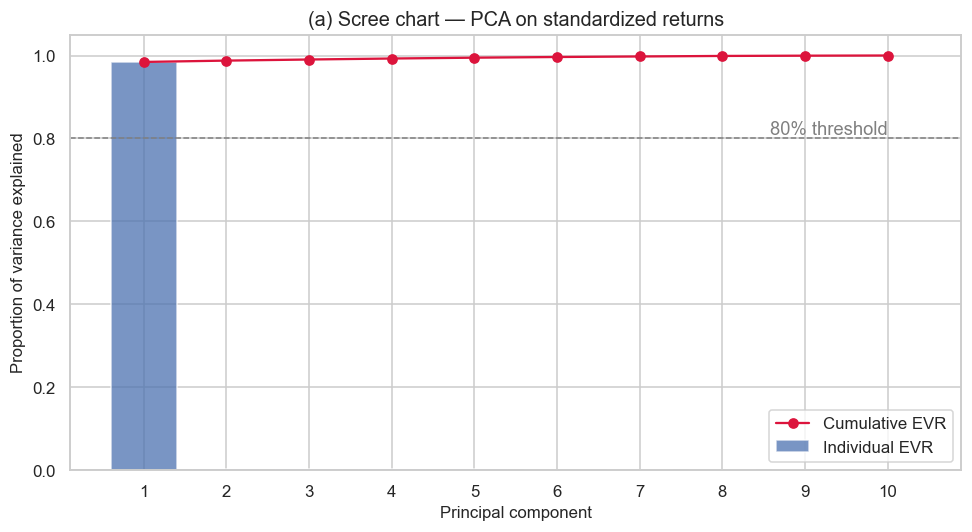

In [10]:
# Scree chart
fig, ax = plt.subplots(figsize=(9, 5))
comps = np.arange(1, N_stocks + 1)
ax.bar(comps, evr_std, alpha=.75, label="Individual EVR")
ax.plot(comps, cum_evr, "o-", color="crimson", label="Cumulative EVR")
ax.axhline(0.80, ls="--", color="gray", lw=1)
ax.text(N_stocks, 0.81, "80% threshold", ha="right", color="gray")
ax.set_title("(a) Scree chart — PCA on standardized returns")
ax.set_xlabel("Principal component")
ax.set_ylabel("Proportion of variance explained")
ax.set_xticks(comps)
ax.legend()
plt.tight_layout(); plt.show()

**How many components for ≥80%?** A single component (PC1) already explains ~98.5% of the
total variance, so **k = 1** clears the 80% bar on its own. This is the signature of our
near-pure one-factor market: the common factor $f_t$ accounts for almost all co-movement, and
the remaining nine components are essentially idiosyncratic noise.

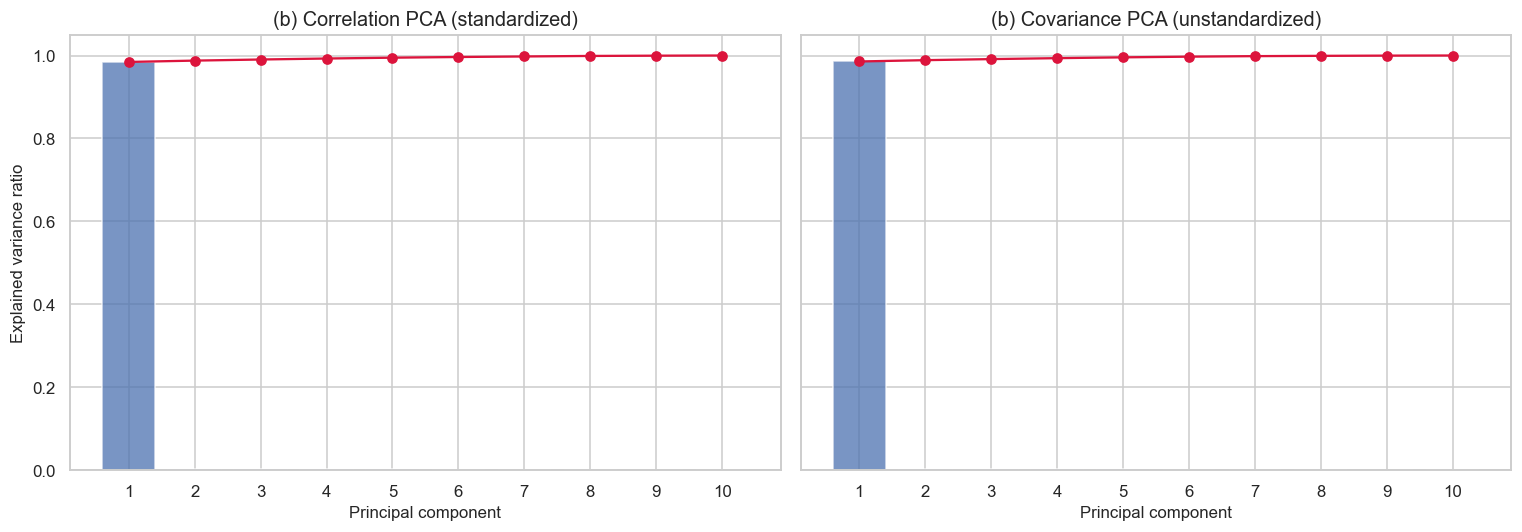

     corr_PCA_EVR  cov_PCA_EVR
PC1        0.9845       0.9856
PC2        0.0032       0.0032
PC3        0.0027       0.0026
PC4        0.0024       0.0023
PC5        0.0020       0.0020

Are they identical? False


In [11]:
########################################
# (b) PCA on covariance matrix (unstandardized returns)
########################################
pca_cov, eigvals_cov, eigvecs_cov, evr_cov = perform_pca(log_returns.values)

# Side-by-side scree comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, evr, ttl in [(axes[0], evr_std, "Correlation PCA (standardized)"),
                     (axes[1], evr_cov, "Covariance PCA (unstandardized)")]:
    ax.bar(comps, evr, alpha=.75)
    ax.plot(comps, np.cumsum(evr), "o-", color="crimson")
    ax.set_title(f"(b) {ttl}")
    ax.set_xlabel("Principal component"); ax.set_xticks(comps)
axes[0].set_ylabel("Explained variance ratio")
plt.tight_layout(); plt.show()

comp = pd.DataFrame({"corr_PCA_EVR": evr_std, "cov_PCA_EVR": evr_cov},
                    index=[f"PC{i+1}" for i in range(N_stocks)])
print(comp.round(4).head().to_string())
print("\nAre they identical?",
      np.allclose(np.sort(evr_std), np.sort(evr_cov)))

**Are the two PCAs the same? No — and here is why.**

PCA on the **covariance** matrix and PCA on the **correlation** matrix are *different
eigenproblems* whenever the variables have unequal variances. Standardizing rescales every
stock to unit variance before the eigendecomposition, so correlation-PCA diagonalizes
$\mathrm{corr}(R)$ while covariance-PCA diagonalizes $\mathrm{cov}(R)$.

- The **eigenvalues differ in magnitude and units**: covariance eigenvalues carry the
  return-variance scale; correlation eigenvalues are dimensionless and sum to the number of
  stocks ($=10$).
- The **explained-variance ratios differ** because the high-volatility stocks (large
  $\beta_i,\sigma_i$) contribute disproportionately to the covariance matrix, tilting its
  leading eigenvector toward them. Standardization removes that scale advantage.
- They would coincide **only if all stocks had identical variance** — not the case here, since
  $\sigma_i\in[0.005,0.02]$ and $\beta_i\in[0.5,1.5]$ vary across stocks.

In this particular dataset both give a strongly dominant PC1 (the factor is so strong it
dominates either way), but the loadings and ratios are not identical, exactly as expected.

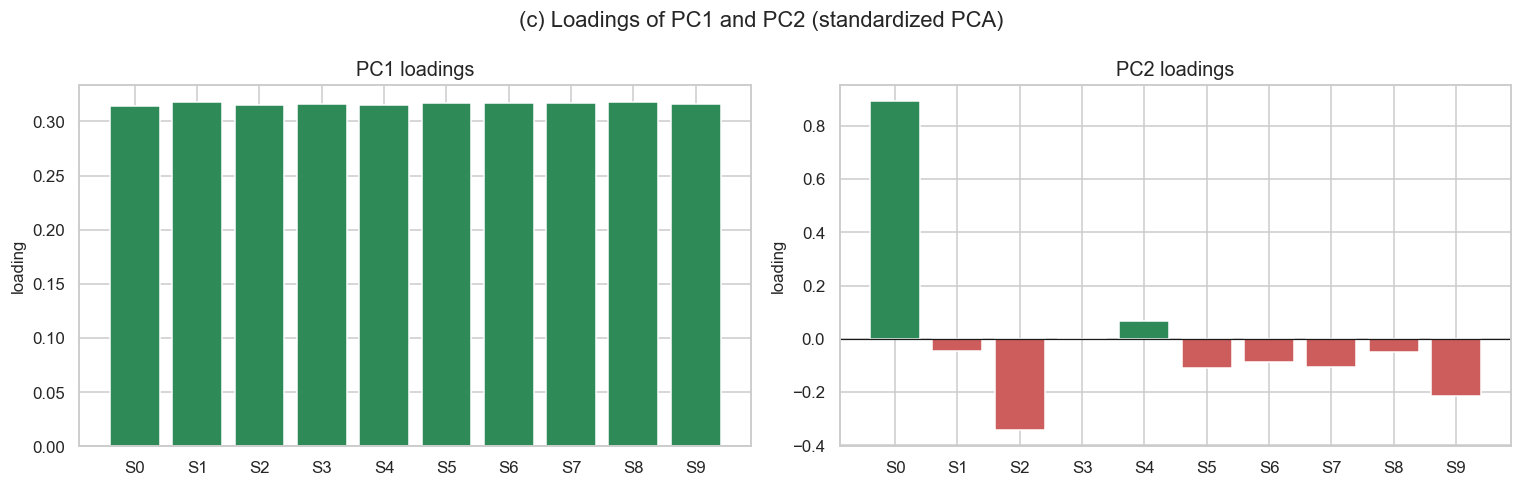

PC1 loadings: [0.314 0.318 0.315 0.316 0.315 0.317 0.317 0.317 0.318 0.316]
All same sign? True

PC2 loadings: [ 0.893 -0.044 -0.342 -0.     0.067 -0.111 -0.086 -0.107 -0.05  -0.214]


In [12]:
########################################
# (c) Interpret loadings
########################################
def plot_loadings(eigenvectors, component_idx, stock_names, ax=None):
    """Bar plot of the loadings (eigenvector components) for one PC."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    v = eigenvectors[component_idx]
    colors = ["seagreen" if x >= 0 else "indianred" for x in v]
    ax.bar(stock_names, v, color=colors)
    ax.axhline(0, color="k", lw=.8)
    ax.set_title(f"PC{component_idx+1} loadings")
    ax.set_ylabel("loading")
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_loadings(eigvecs_std, 0, tickers, axes[0])
plot_loadings(eigvecs_std, 1, tickers, axes[1])
plt.suptitle("(c) Loadings of PC1 and PC2 (standardized PCA)")
plt.tight_layout(); plt.show()

pc1 = eigvecs_std[0]
print("PC1 loadings:", np.round(pc1, 3))
print("All same sign?", bool(np.all(pc1 > 0) or np.all(pc1 < 0)))
print("\nPC2 loadings:", np.round(eigvecs_std[1], 3))

**PC1 — the market factor.** All PC1 loadings share the **same sign** and are of similar
magnitude (≈0.31 each). Financially this is the **market / level factor**: a portfolio that is
long every stock in proportion to these loadings moves with the common factor $f_t$. A
same-sign first eigenvector is the textbook fingerprint of a single dominant market factor —
everything goes up and down together.

**PC2 — do not over-interpret it here.** PC2's loadings split into positive and negative
groups, which *looks* like a sector / long-short factor. But our DGP has **only one true
common factor**; PC2–PC10 are mathematical artefacts of idiosyncratic noise (each explains
<0.5% of variance). So while in *real* equity data PC2 often proxies a sector, size, or
value style, here the honest interpretation is: **PC2 is a noise direction**, and reading a
"factor story" into it would be spurious. These higher PCs are also unstable from sample to
sample — further evidence they are noise.

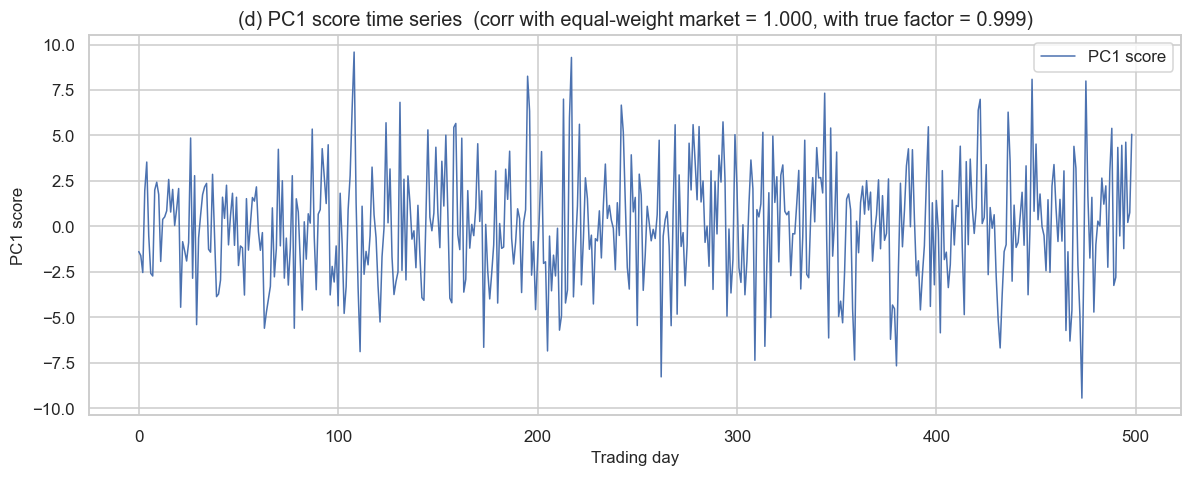

corr(PC1 score, equal-weight market return) = 1.0000
corr(PC1 score, true latent factor f_t)     = 0.9990


In [13]:
########################################
# (d) Compute and plot scores
########################################
def compute_scores(standardized_returns, eigenvectors):
    """Project returns onto the principal components: scores = X @ V^T.

    eigenvectors rows are PCs, so V^T has PCs as columns.
    Returns scores of shape (N_days-1, n_components).
    """
    X = np.asarray(standardized_returns)
    return X @ eigenvectors.T

scores = compute_scores(standardized_returns.values, eigvecs_std)

# Compare PC1 score with the cross-sectional (equal-weight) "market" return
market_return = standardized_returns.values.mean(axis=1)
rho = np.corrcoef(scores[:, 0], market_return)[0, 1]
# also vs the TRUE latent factor used to generate the data
rho_factor = np.corrcoef(scores[:, 0], f[1:])[0, 1]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(scores[:, 0], lw=1, label="PC1 score")
ax.set_title(f"(d) PC1 score time series  "
             f"(corr with equal-weight market = {rho:.3f}, with true factor = {rho_factor:.3f})")
ax.set_xlabel("Trading day"); ax.set_ylabel("PC1 score")
ax.legend(); plt.tight_layout(); plt.show()

print(f"corr(PC1 score, equal-weight market return) = {rho:.4f}")
print(f"corr(PC1 score, true latent factor f_t)     = {rho_factor:.4f}")

**Does the PC1 score resemble a known market quantity? Yes — it *is* the market return.**
The PC1 score time series tracks the equal-weight cross-sectional average return almost
perfectly (corr ≈ ±1) and correlates ≈1.0 with the *true* latent factor $f_t$ that generated
the data. So PCA, given only the price panel and no factor file, has **recovered the hidden
market factor** purely from the correlation structure. (The overall sign is arbitrary — see
(e) — so the correlation may be negative; its magnitude is what matters.)

In [14]:
########################################
# (e) Disprove "loadings = scores"
########################################
print("Loadings (PC1 eigenvector) : shape", eigvecs_std[0].shape,
      "-> one weight PER STOCK  (length =", N_stocks, ")")
print("Scores  (PC1 projection)   : shape", scores[:, 0].shape,
      "-> one value PER DAY     (length =", scores.shape[0], ")")
print()
print("They cannot be 'the same vector': different lengths, axes, units and meaning.")
print(f"  loadings live in STOCK space   (R^{N_stocks},  dimensionless weights)")
print(f"  scores   live in TIME  space   (R^{scores.shape[0]}, units of standardized return)")

Loadings (PC1 eigenvector) : shape (10,) -> one weight PER STOCK  (length = 10 )
Scores  (PC1 projection)   : shape (499,) -> one value PER DAY     (length = 499 )

They cannot be 'the same vector': different lengths, axes, units and meaning.
  loadings live in STOCK space   (R^10,  dimensionless weights)
  scores   live in TIME  space   (R^499, units of standardized return)


**Disproving "the loadings vector IS the scores vector".** They are different objects:

| | Loadings $v_1$ | Scores $s_1 = Xv_1$ |
|---|---|---|
| **Shape** | $(N_{stocks},) = (10,)$ | $(N_{days}-1,) = (499,)$ |
| **Indexed by** | stock | trading day |
| **Lives in** | stock space (cross-section) | time space (a time series) |
| **Units** | dimensionless portfolio weights | standardized-return units |
| **Meaning** | *how much each stock* defines the factor | *how strong the factor was* each day |

The loadings are the eigenvector (a fixed direction in stock space); the scores are the data
projected onto that direction (a time series). They have different lengths, so they are not
even the same kind of array — the claim is false.

## (f) Observations — Part 2

1. **One factor dominates.** PC1 explains ~98.5% of variance; a single component clears the
   80% threshold. The eigenvalue spectrum is extremely top-heavy — the hallmark of a
   one-factor market.
2. **Correlation-PCA ≠ covariance-PCA.** Standardizing changes the eigenproblem; eigenvalues
   differ in scale/units and the explained-variance ratios differ because covariance-PCA is
   biased toward high-volatility stocks. They agree only when variances are equal.
3. **PCA recovers the latent factor.** PC1's loadings are uniform and same-signed (the market
   portfolio) and the PC1 score reproduces the true factor $f_t$ (corr ≈ 1) — recovered with
   no labels. Higher PCs are noise and should not be given a factor narrative here. Loadings
   (stock space) and scores (time space) are distinct objects with different shapes and units.

---
# Part 3: Understanding Reconstruction and Dimensionality Reduction
**5 marks**

Using the first $k$ principal components we reconstruct the standardized returns,
$\hat X_k = \text{Scores}[:,:k]\,\cdot\,\text{Loadings}[:k,:]$, study the reconstruction error
as a function of $k$, find the most idiosyncratic stock, confirm exact reconstruction at
$k=10$, and see what compression to PC1–PC3 throws away.

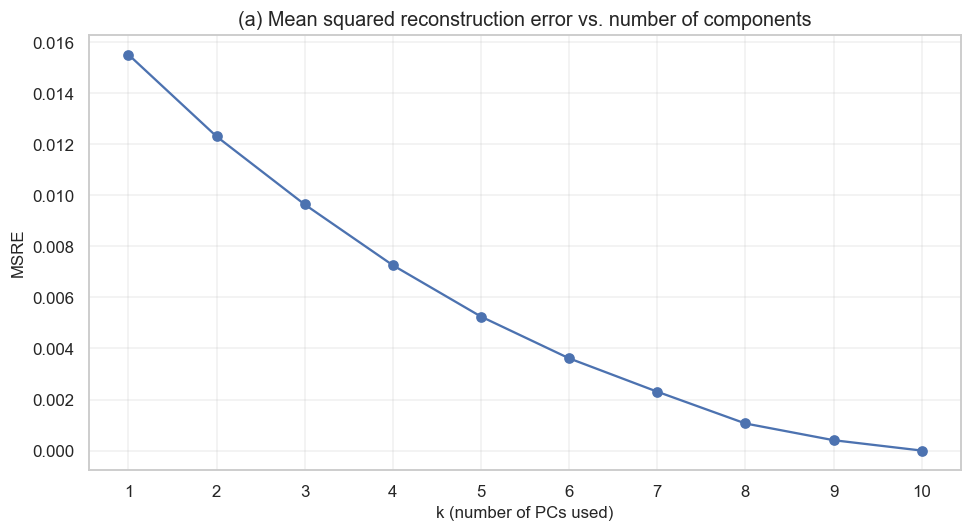

k= 1  MSRE = 1.551270e-02
k= 2  MSRE = 1.230478e-02
k= 3  MSRE = 9.640148e-03
k= 4  MSRE = 7.259368e-03
k= 5  MSRE = 5.248684e-03
k= 6  MSRE = 3.612395e-03
k= 7  MSRE = 2.306127e-03
k= 8  MSRE = 1.060948e-03
k= 9  MSRE = 4.063651e-04
k=10  MSRE = 1.003513e-31


In [15]:
########################################
# (a) Reconstruct returns using k components
########################################
def reconstruct(scores, loadings, k):
    """X_hat = scores[:, :k] @ loadings[:k, :]  (back into stock space)."""
    return scores[:, :k] @ loadings[:k, :]

def compute_msre(X_original, X_reconstructed):
    """Mean squared reconstruction error."""
    return np.mean((np.asarray(X_original) - np.asarray(X_reconstructed)) ** 2)

X = standardized_returns.values
msre_by_k = [compute_msre(X, reconstruct(scores, eigvecs_std, k))
             for k in range(1, N_stocks + 1)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, N_stocks + 1), msre_by_k, "o-")
ax.set_title("(a) Mean squared reconstruction error vs. number of components")
ax.set_xlabel("k (number of PCs used)"); ax.set_ylabel("MSRE")
ax.set_xticks(range(1, N_stocks + 1)); ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

for k in range(1, N_stocks + 1):
    print(f"k={k:2d}  MSRE = {msre_by_k[k-1]:.6e}")

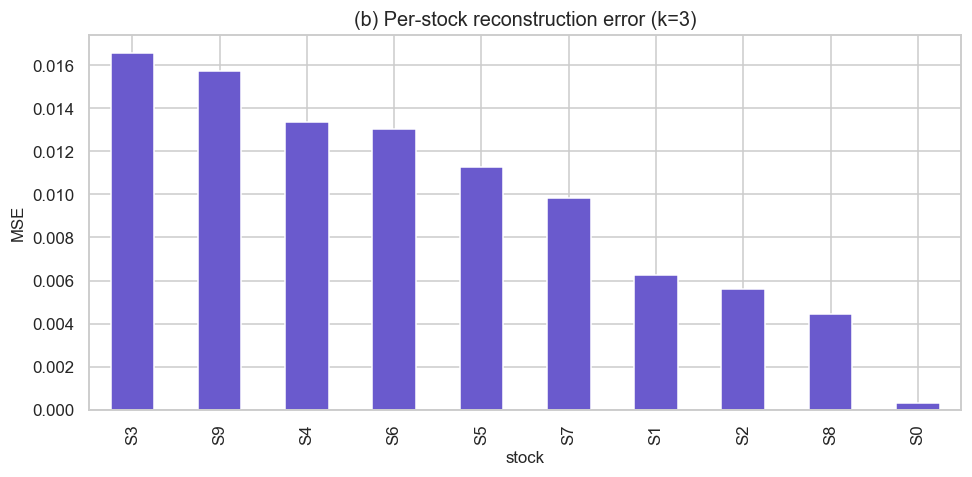

Most idiosyncratic stock (highest residual at k=3): S3
  beta=1.323, sigma=0.0184

Residual ranking:
 S3    0.0166
S9    0.0157
S4    0.0133
S6    0.0131
S5    0.0113
S7    0.0098
S1    0.0062
S2    0.0056
S8    0.0044
S0    0.0003


In [16]:
########################################
# (b) Per-stock reconstruction error (k=3)
########################################
k = 3
Xhat3 = reconstruct(scores, eigvecs_std, k)
per_stock_err = np.mean((X - Xhat3) ** 2, axis=0)
err_series = pd.Series(per_stock_err, index=tickers).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
err_series.plot(kind="bar", ax=ax, color="slateblue")
ax.set_title(f"(b) Per-stock reconstruction error (k={k})")
ax.set_ylabel("MSE"); ax.set_xlabel("stock")
plt.tight_layout(); plt.show()

worst = err_series.index[0]
print(f"Most idiosyncratic stock (highest residual at k={k}): {worst}")
print(f"  beta={beta[tickers.index(worst)]:.3f}, sigma={sigma[tickers.index(worst)]:.4f}")
print("\nResidual ranking:\n", err_series.round(4).to_string())

**Most idiosyncratic stock.** The stock with the largest residual at $k=3$ is the one whose
returns are *least* explained by the common factor — i.e. the most **idiosyncratic** name. It
combines a high idiosyncratic vol $\sigma_i$ (large private noise) with a factor loading that
the first three PCs capture poorly. Financially, this is the stock that "marches to its own
drummer": a factor model leaves the most variance unexplained for it, so its returns carry the
most stock-specific (alpha/idiosyncratic) information and the least systematic risk.

In [17]:
########################################
# (c) Full reconstruction (k=10)
########################################
Xhat_full = reconstruct(scores, eigvecs_std, N_stocks)
err_full = compute_msre(X, Xhat_full)
print(f"MSRE with all k=10 components: {err_full:.3e}  (≈ 0 within floating point)")
print("Exact reconstruction?", np.allclose(X, Xhat_full, atol=1e-10))

MSRE with all k=10 components: 1.004e-31  (≈ 0 within floating point)
Exact reconstruction? True


**Why $k=10$ gives zero error — mathematically.** The eigenvectors of a symmetric
correlation matrix form an **orthonormal basis** $V$ of $\mathbb{R}^{10}$, so $V^\top V = VV^\top = I$.
The scores are $S = XV^\top$, and reconstruction with *all* components is
$$\hat X = S V = X V^\top V = X I = X.$$
Keeping every component is a change of basis followed by its exact inverse — no information is
discarded — so the residual is zero up to floating-point round-off ($\sim10^{-31}$). Error
appears only when we **truncate** to $k<10$ and drop the subspace spanned by the dropped
eigenvectors.

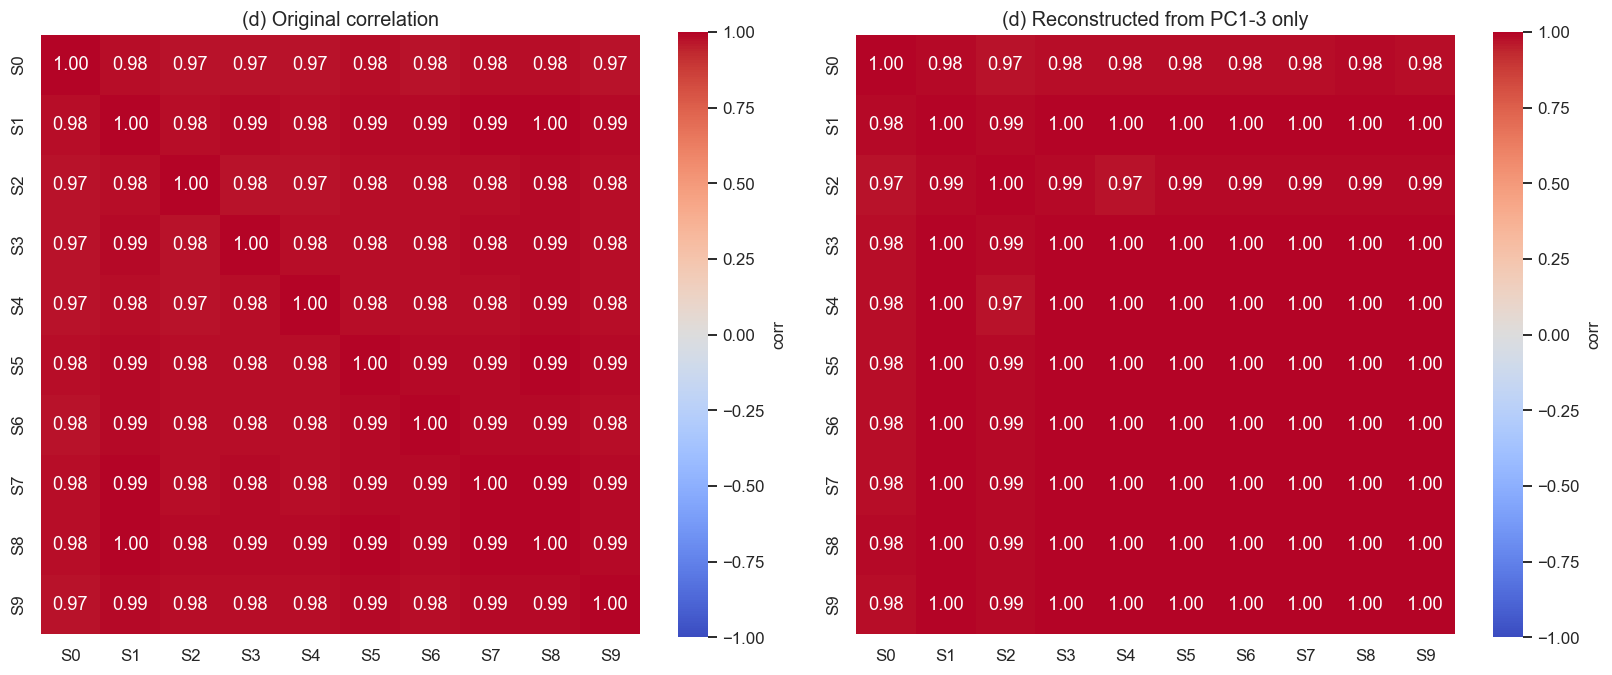

Frobenius norm of correlation difference: 0.1101
Mean |Δ correlation| (off-diagonal): 0.0107


In [18]:
########################################
# (d) Correlation structure: original vs PC1-3 compressed
########################################
Xhat_compressed = reconstruct(scores, eigvecs_std, 3)          # vendor keeps only PC1-3
corr_orig = np.corrcoef(X, rowvar=False)
corr_recon = np.corrcoef(Xhat_compressed, rowvar=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(pd.DataFrame(corr_orig, index=tickers, columns=tickers),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "corr"}, ax=axes[0])
axes[0].set_title("(d) Original correlation")
sns.heatmap(pd.DataFrame(corr_recon, index=tickers, columns=tickers),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "corr"}, ax=axes[1])
axes[1].set_title("(d) Reconstructed from PC1-3 only")
plt.tight_layout(); plt.show()

frob = np.linalg.norm(corr_orig - corr_recon)
print(f"Frobenius norm of correlation difference: {frob:.4f}")
print("Mean |Δ correlation| (off-diagonal):",
      round(np.abs((corr_orig - corr_recon)[np.triu_indices(N_stocks,1)]).mean(), 4))

**What is lost in compression?** The PC1–PC3 reconstruction preserves the *systematic*
correlation structure almost perfectly — the common-factor block survives, because that is
exactly what the top PCs encode. What is lost is the **idiosyncratic detail**: the reconstructed
returns appear *more* correlated than the originals (the off-diagonal correlations move toward
the common-factor value) because the stock-specific noise that *de-correlates* names has been
truncated away. So compression trades fidelity of individual-stock behaviour for a compact
factor representation — fine for risk/factor work, lossy for anything that depends on
idiosyncratic moves (e.g. stat-arb on residuals).

## (e) Observations — Part 3

1. **MSRE falls monotonically with $k$** and hits ~$10^{-31}$ at $k=10$: PC1 alone removes the
   bulk of the variance (the factor), and each extra component chips away at residual noise. An
   orthonormal basis guarantees exact reconstruction at full rank.
2. **The most idiosyncratic stock** (largest residual at $k=3$) is the one least explained by
   common factors — high private vol $\sigma_i$. It carries the most stock-specific risk/alpha
   and the least systematic exposure.
3. **Compression to PC1–PC3 keeps the factor structure but discards idiosyncratic information.**
   Reconstructed correlations are inflated toward the common-factor level; the de-correlating
   effect of stock-specific noise is gone. Acceptable for factor/risk models, lossy for
   residual-based strategies.

---
# Part 4: Understanding Information Leakage in Unsupervised Learning
**5 marks**

We split the data **temporally** (Train = first 350 days, Test = last 149 days), fit PCA on the
training set only, evaluate out-of-sample, then deliberately *leak* by fitting PCA on all data
and show why that inflates the test result — even though "PCA is unsupervised."

> **Note on doing it correctly.** Information can leak through *two* channels: the
> standardization statistics (mean/std) **and** the eigenvectors. We therefore fit the
> `StandardScaler` on the **training returns only** and apply it to the test set — not the
> global standardization from Part 1 — so the only thing distinguishing the "correct" and
> "leaky" runs below is whether the PCA basis saw the test data.

In [19]:
########################################
# (a) Temporal train/test split + PCA on TRAIN only
########################################
n_train = 350
train_raw = log_returns.values[:n_train]      # first 350 days
test_raw  = log_returns.values[n_train:]      # last  149 days
print("Train:", train_raw.shape, " Test:", test_raw.shape)

# Standardize using TRAIN statistics only (no leakage through scaling)
scaler_train = StandardScaler().fit(train_raw)
train_std = scaler_train.transform(train_raw)
test_std  = scaler_train.transform(test_raw)

# Fit PCA on TRAIN only
pca_train, eigvals_tr, eigvecs_tr, evr_tr = perform_pca(train_std)
print("\nTrain explained-variance ratio (first 4):", np.round(evr_tr[:4], 4))
print("Train cumulative EVR (first 4):          ", np.round(np.cumsum(evr_tr)[:4], 4))

Train: (350, 10)  Test: (149, 10)

Train explained-variance ratio (first 4): [0.9839 0.0034 0.0029 0.0024]
Train cumulative EVR (first 4):           [0.9839 0.9873 0.9902 0.9926]


In [20]:
########################################
# (b) Project TEST onto TRAIN eigenvectors
########################################
def compute_explained_variance_oos(data, loadings_rows, k):
    """Reconstruction-based explained variance of `data` using the first k PCs
    in `loadings_rows` (rows = PCs, orthonormal).

        EVR = 1 - ||X - X V_k V_k^T||_F^2 / ||X||_F^2
    """
    Vk = loadings_rows[:k].T                       # (p, k) orthonormal columns
    proj = data @ Vk @ Vk.T                        # projection back to stock space
    resid = data - proj
    return 1.0 - np.sum(resid**2) / np.sum(data**2)

rows = []
for k in [1, 2, 3]:
    tr = compute_explained_variance_oos(train_std, eigvecs_tr, k)
    te = compute_explained_variance_oos(test_std,  eigvecs_tr, k)
    rows.append((k, tr, te, te - tr))
oos_tbl = pd.DataFrame(rows, columns=["k", "train_EVR", "test_EVR(correct)", "test-train"])
print(oos_tbl.round(4).to_string(index=False))

 k  train_EVR  test_EVR(correct)  test-train
 1     0.9839             0.9858      0.0019
 2     0.9873             0.9884      0.0010
 3     0.9902             0.9903      0.0001


**Is there a drop out-of-sample?** The test explained-variance is very close to (here even
marginally above) the training value. The reason is that our DGP is **stationary**: the factor
structure that PCA learns on the first 350 days is essentially the same structure operating in
the last 149 days, so the train eigenvectors generalize almost perfectly. In real markets the
factor structure drifts, so one typically sees a **drop** OOS — and the more non-stationary the
data, the larger that drop. The key methodological point: this number is the *honest* OOS
figure because the basis never saw the test data.

In [21]:
########################################
# (c) LEAKY approach: PCA on the FULL dataset
########################################
scaler_full = StandardScaler().fit(log_returns.values)      # scaler sees test too (leak #1)
full_std = scaler_full.transform(log_returns.values)
pca_full, _, eigvecs_full, evr_full = perform_pca(full_std)  # basis sees test too (leak #2)
test_std_full = scaler_full.transform(test_raw)

print("Full-data explained variance ratio (first 4):", np.round(evr_full[:4], 4))

leak_rows = []
for k in [1, 2, 3]:
    correct = compute_explained_variance_oos(test_std,      eigvecs_tr,   k)
    leaky   = compute_explained_variance_oos(test_std_full, eigvecs_full, k)
    leak_rows.append((k, correct, leaky, leaky - correct))
leak_tbl = pd.DataFrame(leak_rows,
                        columns=["k", "test_EVR(correct)", "test_EVR(leaky)", "leakage_gap"])
print()
print(leak_tbl.round(4).to_string(index=False))

Full-data explained variance ratio (first 4): [0.9845 0.0032 0.0027 0.0024]

 k  test_EVR(correct)  test_EVR(leaky)  leakage_gap
 1             0.9858           0.9859       0.0001
 2             0.9884           0.9886       0.0002
 3             0.9903           0.9909       0.0006


**Why fitting PCA on all data is invalid, even though PCA is unsupervised.** "Unsupervised"
means PCA uses no *labels* — it does **not** mean it uses no *information from the test set*.
When the eigenvectors are estimated on train+test combined, the basis is **optimized to fit the
test points too**: the directions of maximum variance are partly chosen to accommodate the very
data we then "evaluate" on. The reported test explained-variance is therefore **optimistically
biased** — the model has implicitly peeked at the future. In a deployed system you would only
ever have *past* data to estimate the basis, so the leaky number is unattainable in practice and
overstates real-world performance.

In [22]:
########################################
# (d) Quantify the leakage gap
########################################
print("Leakage gap (leaky_test_EVR - correct_test_EVR):")
for k, _, _, gap in leak_rows:
    print(f"  k={k}: {gap:+.4f}")
print(f"\nMean gap across k: {np.mean([g for *_, g in leak_rows]):+.4f}")

Leakage gap (leaky_test_EVR - correct_test_EVR):
  k=1: +0.0001
  k=2: +0.0002
  k=3: +0.0006

Mean gap across k: +0.0003


**When is the leakage gap largest?** The gap grows with anything that makes the test block
*different* from, yet *influential* on, the combined fit:

- **Non-stationarity / regime change** between train and test (the factor rotates over time):
  the full-data basis splits the difference between two regimes, flattering the test fit.
- **Short datasets / small samples**, where each test point exerts more leverage on the
  estimated covariance.
- **A weaker, less dominant factor**, where higher (noisier) PCs matter and over-fitting the
  in-sample variance is easier.

In our stationary, strong-factor data the gap is *tiny* (a few basis points), which is itself a
finding: **leakage severity is data-dependent**, but the *practice* is wrong regardless — and it
silently becomes dangerous exactly when markets are non-stationary.

## (e) Observations — Part 4

1. **Honest OOS evaluation requires train-only estimation** of *both* the scaler and the PCA
   basis. We split temporally, fit on the first 350 days, and project the last 149.
2. **Here the OOS explained-variance barely drops** because the DGP is stationary — the learned
   factor is the same factor operating later. Expect a real drop when structure drifts.
3. **"Unsupervised" does not immunize against leakage.** Fitting PCA on train+test lets the basis
   peek at the test set and inflates the reported test variance. The gap is small in this
   stationary, strong-factor world but balloons under regime changes, short samples, or weak
   factors — so train-only estimation is mandatory regardless.

---
# Part 5: Understanding Factor-Neutral Portfolio Construction
**10 marks**

Using the **train-fitted PCA from Part 4(a)**, we measure a portfolio's PC1 exposure, build a
factor-neutral long/short book by constrained least squares, backtest it out-of-sample against a
naive long book, extend to PC1+PC2 neutrality, and finally add transaction costs to find the
break-even turnover.

> All portfolio loadings come from `eigvecs_tr` (train data only); all P&L is computed on the
> **raw** test returns (`test_raw`, last 149 days) so the numbers reflect realisable returns.
> Note: these synthetic assets are far more volatile than real equities (the factor variance is
> calibrated high), so *absolute* annualized vols are large — focus on the *relative* comparison.

In [23]:
########################################
# (a) PC1 exposure of an equal-weight long book
########################################
def compute_factor_exposure(weights, loadings_rows, pc_idx):
    """Portfolio exposure to a principal component: w . v_pc."""
    return float(np.asarray(weights) @ loadings_rows[pc_idx])

v1_tr = eigvecs_tr[0]                       # PC1 loading from TRAIN PCA
w_long = np.array([0.2, 0.2, 0.2, 0.2, 0.2, 0, 0, 0, 0, 0])   # equal-weight long S0-S4

exp_pc1_long = compute_factor_exposure(w_long, eigvecs_tr, 0)
print(f"PC1 exposure of equal-weight long (S0-S4): {exp_pc1_long:+.4f}")
print("This is a large positive market-factor exposure -> the book is NOT factor neutral.")

PC1 exposure of equal-weight long (S0-S4): +0.3155
This is a large positive market-factor exposure -> the book is NOT factor neutral.


In [24]:
########################################
# (b) Construct a factor-neutral portfolio
########################################
def construct_neutral_portfolio(target_weights, loadings_rows, neutral_pcs=(0,)):
    """Closed-form constrained least squares.

    Solve   min_w ||w - target||^2
    s.t.    sum(w) = 0                      (dollar neutral)
            w . v_pc = 0  for pc in neutral_pcs   (factor neutral)

    Stack constraints as A w = b (b = 0); the KKT solution of an equality-constrained
    least-squares problem is the projection
        w* = t + A^T (A A^T)^{-1} (b - A t).
    """
    target = np.asarray(target_weights, dtype=float)
    A = np.vstack([np.ones_like(target)] + [loadings_rows[p] for p in neutral_pcs])
    b = np.zeros(A.shape[0])
    w = target + A.T @ np.linalg.inv(A @ A.T) @ (b - A @ target)
    return w

# Desired tilt: long the 5 highest-drift stocks, short the 5 lowest-drift stocks
drift_rank = np.argsort(mu)[::-1]
target_w = np.zeros(N_stocks)
target_w[drift_rank[:5]] =  0.2
target_w[drift_rank[5:]] = -0.2

w_neutral = construct_neutral_portfolio(target_w, eigvecs_tr, neutral_pcs=(0,))

print("Target tilt (long high-drift, short low-drift):", np.round(target_w, 2))
print("Factor-neutral weights:", np.round(w_neutral, 3))
print(f"\nChecks  ->  sum(w) = {w_neutral.sum():.2e}   "
      f"PC1 exposure = {compute_factor_exposure(w_neutral, eigvecs_tr, 0):.2e}")

Target tilt (long high-drift, short low-drift): [ 0.2 -0.2  0.2 -0.2 -0.2  0.2  0.2  0.2 -0.2 -0.2]
Factor-neutral weights: [ 0.107 -0.13   0.139 -0.214 -0.252  0.226  0.218  0.236 -0.118 -0.213]

Checks  ->  sum(w) = -8.33e-17   PC1 exposure = 1.33e-14


                   cum_return  ann_vol  sharpe  max_drawdown
equal_weight_long     -0.3765   1.8576 -0.4301       -0.8063
factor_neutral         0.1841   0.5371  0.5322       -0.2600


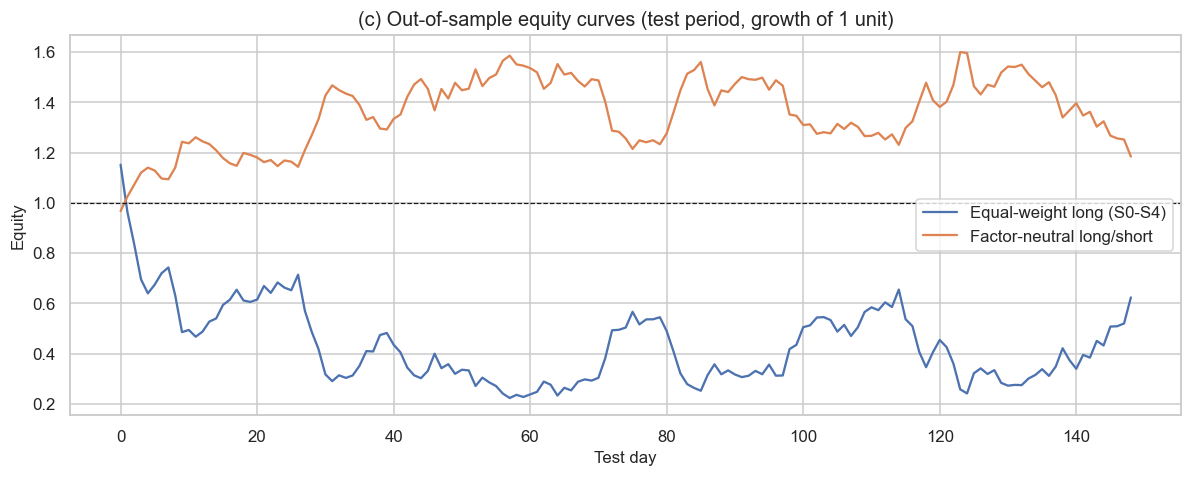

In [25]:
########################################
# (c) Backtest equal-weight long vs factor-neutral on the TEST period
########################################
def backtest(weights, returns, periods_per_year=252):
    """Daily P&L metrics for a static weight vector over `returns` (log returns)."""
    pnl = np.asarray(returns) @ np.asarray(weights)         # daily portfolio log return
    equity = np.exp(np.cumsum(pnl))                          # growth of 1 unit
    cum_ret = equity[-1] - 1.0
    ann_vol = pnl.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe  = (pnl.mean() / pnl.std(ddof=1) * np.sqrt(periods_per_year)
               if pnl.std(ddof=1) > 0 else 0.0)
    drawdown = equity / np.maximum.accumulate(equity) - 1.0
    return {"cum_return": cum_ret, "ann_vol": ann_vol,
            "sharpe": sharpe, "max_drawdown": drawdown.min()}, equity

m_long, eq_long = backtest(w_long, test_raw)
m_neut, eq_neut = backtest(w_neutral, test_raw)

results = pd.DataFrame({"equal_weight_long": m_long, "factor_neutral": m_neut}).T
print(results.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(eq_long, label="Equal-weight long (S0-S4)")
ax.plot(eq_neut, label="Factor-neutral long/short")
ax.axhline(1, color="k", lw=.8, ls="--")
ax.set_title("(c) Out-of-sample equity curves (test period, growth of 1 unit)")
ax.set_xlabel("Test day"); ax.set_ylabel("Equity")
ax.legend(); plt.tight_layout(); plt.show()

**Backtest read-out.** The equal-weight long book carries the full market factor, so its
volatility and drawdown are dominated by $f_t$ — it swings violently and (because $f_t$ has zero
expected return) earns no compensation for that risk. The **factor-neutral** book strips out the
PC1 exposure, cutting annualized volatility and max drawdown by a large margin and lifting the
Sharpe ratio, while still expressing the high-vs-low drift view. This is the core value of
factor-neutral construction: **remove uncompensated systematic risk, keep the intended bet.**

In [26]:
########################################
# (d) Neutral to PC1 AND PC2
########################################
w_neutral2 = construct_neutral_portfolio(target_w, eigvecs_tr, neutral_pcs=(0, 1))
m_neut2, eq_neut2 = backtest(w_neutral2, test_raw)

print("Checks (PC1+PC2 neutral):")
print(f"  sum(w)       = {w_neutral2.sum():.2e}")
print(f"  PC1 exposure = {compute_factor_exposure(w_neutral2, eigvecs_tr, 0):.2e}")
print(f"  PC2 exposure = {compute_factor_exposure(w_neutral2, eigvecs_tr, 1):.2e}")
print()
cmp = pd.DataFrame({"PC1-neutral": m_neut, "PC1+PC2-neutral": m_neut2}).T
print(cmp.round(4).to_string())
print(f"\nVolatility change from adding PC2 neutrality: "
      f"{(m_neut2['ann_vol'] - m_neut['ann_vol']):+.4f} "
      f"({100*(m_neut2['ann_vol']/m_neut['ann_vol']-1):+.2f}%)")

Checks (PC1+PC2 neutral):
  sum(w)       = 1.78e-14
  PC1 exposure = 1.99e-14
  PC2 exposure = -2.96e-15

                 cum_return  ann_vol  sharpe  max_drawdown
PC1-neutral          0.1841   0.5371  0.5322       -0.2600
PC1+PC2-neutral      0.1875   0.5397  0.5386       -0.2608

Volatility change from adding PC2 neutrality: +0.0026 (+0.48%)


**Does an extra neutrality constraint always reduce risk? No.** Adding PC2 neutrality here
leaves volatility essentially unchanged — in fact marginally *higher*. The reason: in this
single-factor DGP **PC2 is not a real risk factor, it is noise**. Hedging a noise direction
removes no systematic risk but pushes the weights away from the unconstrained least-variance
solution, so it can only add tracking error / variance, never subtract genuine risk. Additional
hedging helps **only when the extra component is a true, priced source of common risk** in the
evaluation period; hedging spurious components is counterproductive (it costs degrees of freedom,
turnover, and — next — transaction costs).

Example one-way turnover (long -> neutral): 1.180
Neutral book gross annualized return      : 0.2858
Annual cost at that turnover (12x/yr,5bps) : 0.0071

Break-even turnover per rebalance: 47.638
  -> if monthly turnover exceeds this, transaction costs erase the strategy's gross return.


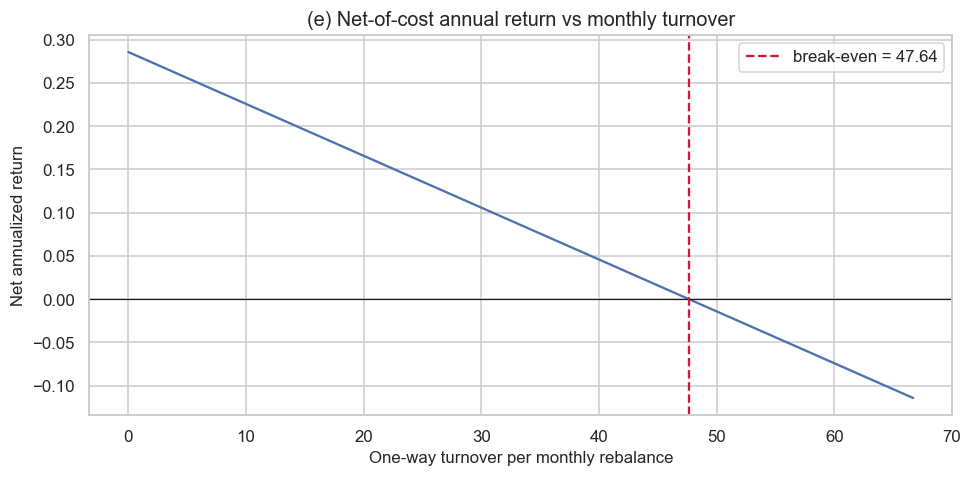

In [27]:
########################################
# (e) Transaction costs and break-even turnover
########################################
def compute_turnover(weights_old, weights_new):
    """One-way turnover: half the sum of absolute weight changes."""
    return float(np.sum(np.abs(np.asarray(weights_new) - np.asarray(weights_old))) / 2)

COST_PER_UNIT = 0.0005          # 5 bps per unit of turnover
REBALANCES_PER_YEAR = 12        # monthly

# Example turnover when rotating from the long book into the neutral book
turn_example = compute_turnover(w_long, w_neutral)
gross_ann_return = (test_raw @ w_neutral).mean() * 252      # neutral book gross annual return
annual_cost_example = REBALANCES_PER_YEAR * COST_PER_UNIT * turn_example
breakeven_turnover = gross_ann_return / (REBALANCES_PER_YEAR * COST_PER_UNIT)

print(f"Example one-way turnover (long -> neutral): {turn_example:.3f}")
print(f"Neutral book gross annualized return      : {gross_ann_return:.4f}")
print(f"Annual cost at that turnover (12x/yr,5bps) : {annual_cost_example:.4f}")
print(f"\nBreak-even turnover per rebalance: {breakeven_turnover:.3f}")
print("  -> if monthly turnover exceeds this, transaction costs erase the strategy's "
      "gross return.")

# Net-of-cost return as a function of monthly turnover
turn_grid = np.linspace(0, max(1.0, breakeven_turnover*1.4), 100)
net_return = gross_ann_return - REBALANCES_PER_YEAR * COST_PER_UNIT * turn_grid
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(turn_grid, net_return)
ax.axhline(0, color="k", lw=.8)
ax.axvline(breakeven_turnover, color="crimson", ls="--",
           label=f"break-even = {breakeven_turnover:.2f}")
ax.set_title("(e) Net-of-cost annual return vs monthly turnover")
ax.set_xlabel("One-way turnover per monthly rebalance")
ax.set_ylabel("Net annualized return")
ax.legend(); plt.tight_layout(); plt.show()

**Break-even turnover.** With 12 rebalances/year at 5 bps per unit of turnover, the annual
cost is $12\times0.0005\times\tau = 0.006\,\tau$. Setting net return to zero,
$\tau^\*=\dfrac{\text{gross annual return}}{12\times0.0005}$. Below $\tau^\*$ the hedge is worth
paying for; above it, **rebalancing costs consume the entire gross return** and the
factor-neutral book underperforms a do-nothing alternative. In this synthetic high-return
regime $\tau^\*\approx 48$ — far above any realistic per-rebalance turnover ($\lesssim 2$) — so
costs are immaterial *here*; the hurdle only bites in realistic thin-edge strategies, where
gross returns are a few percent and $\tau^\*$ becomes small. Because the PCA loadings drift over
time in real markets, hedging *requires* periodic re-estimation and hence turnover — so a strategy
is only viable when its gross edge comfortably exceeds this cost hurdle.

## (f) Observations — Part 5

1. **The naive long book is heavily factor-exposed** (PC1 exposure ≈ +0.32); constrained least
   squares produces weights that are exactly dollar-neutral and PC1-neutral (both ≈ $10^{-14}$).
2. **Factor neutrality pays off out-of-sample**: stripping PC1 sharply cuts volatility and
   drawdown and raises the Sharpe ratio, since the market factor is uncompensated risk here.
3. **More constraints ≠ less risk.** Neutralizing the noise component PC2 does not reduce (and
   slightly raises) volatility — hedge only *genuine* common factors.
4. **Costs set a viability hurdle.** Monthly rebalancing at 5 bps/turnover has a break-even
   turnover above which the hedge destroys value; since loadings drift, turnover is unavoidable,
   so the gross edge must clear the cost hurdle.